# Final performance

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)

from attention_lapse_detection.detection.detector import Detector
from attention_lapse_detection.training.metrics import (
    per_clip,
    predict,
    best_f1_threshold_extended,
)
from attention_lapse_detection.training.selection import CELL, select, select_per_model
from attention_lapse_detection.utils.constants import SEED
from attention_lapse_detection.utils.paths import PATHS
from attention_lapse_detection.utils.checkpoints import resolve_checkpoint
from attention_lapse_detection.training.report import mean_sd
from attention_lapse_detection.utils.data_paths import load_clean_split
from attention_lapse_detection.training.data import load_clip_ids

PROBS = PATHS.experiments / "results/test_probs"

In [29]:
all_runs = pd.read_csv(PATHS.experiments / "results/thesis_runs.csv")

SELECTED_CELLS = select_per_model(all_runs)

MODEL, FPS, WINDOW = select(all_runs)

full_runs = all_runs[all_runs.features == "all_features"]

selected_runs = full_runs.merge(pd.DataFrame(SELECTED_CELLS.values(), columns=CELL))

all_test_results = pd.read_csv(PATHS.experiments / "results/test_results.csv").merge(
    all_runs[["checkpoint", "model", "seed"]]
)

test_results = all_test_results.loc[
    all_test_results.checkpoint.isin(selected_runs.checkpoint)
].reset_index(drop=True)

retained_results = (
    test_results[test_results.model == MODEL].sort_values("seed").reset_index(drop=True)
)

DELIVERABLE_ROW = retained_results.seed.tolist().index(SEED)
deliverable = retained_results.loc[DELIVERABLE_ROW]

test = pd.read_csv(PROBS / f"{deliverable.checkpoint}.csv")

N_CLIPS = len(test)
PREVALENCE = test.y.mean()

print(
    f"{len(test_results)} principal checkpoints: {N_CLIPS} test clips, {test.y.sum()} disengaged, "
    f"{test.participant.nunique()} participants; AP reference {PREVALENCE:.4f}"
)

32 principal checkpoints: 1753 test clips, 84 disengaged, 21 participants; AP reference 0.0479


## Table 6.4 Final test metrics and the always-engaged baseline

In [3]:
METRICS = {
    "Clip AP": "test_clip_ap",
    "Precision": "test_precision_disengaged",
    "Recall": "test_recall_disengaged",
    "Weighted F1": "test_weighted_f1",
    "Accuracy": "test_accuracy",
}

MODEL_NAMES = {
    "gru": "GRU",
    "lstm": "LSTM",
    "gru_uni_attention": "GRU + attention",
    "lstm_uni_attention": "LSTM + attention",
}

rows = {}

for model, name in MODEL_NAMES.items():
    seed_rows = test_results[test_results.model == model]

    _, fps, window = SELECTED_CELLS[model]

    rows[f"{name} ({fps}fps / {window}s)"] = [
        mean_sd(seed_rows[column].mean(), seed_rows[column].std())
        for column in METRICS.values()
    ]

never = np.zeros(N_CLIPS, dtype=int)

rows["Always engaged"] = [
    f"{average_precision_score(test.y, never):.4f}",
    "-",
    f"{recall_score(test.y, never):.4f}",
    f"{f1_score(test.y, never, average='weighted'):.4f}",
    f"{accuracy_score(test.y, never):.4f}",
]

pd.DataFrame.from_dict(rows, orient="index", columns=list(METRICS))

,Clip AP,Precision,Recall,Weighted F1,Accuracy
GRU (30fps / 10s),0.1444 ± 0.0242,0.0848 ± 0.0106,0.4955 ± 0.1055,0.7918 ± 0.0504,0.7117 ± 0.0736
LSTM (30fps / 10s),0.1458 ± 0.0194,0.0817 ± 0.0051,0.6220 ± 0.1041,0.7439 ± 0.0490,0.6450 ± 0.0624
GRU + attention (10fps / 10s),0.1641 ± 0.0199,0.1032 ± 0.0119,0.6682 ± 0.0684,0.7841 ± 0.0437,0.6994 ± 0.0602
LSTM + attention (30fps / 10s),0.1389 ± 0.0157,0.1147 ± 0.0200,0.6860 ± 0.0646,0.7994 ± 0.0435,0.7210 ± 0.0631
Always engaged,0.0479,-,0.0000,0.9287,0.9521


## Figure 6.4 Validation threshold and test precision–recall behaviour

validation AP 0.2836 (stored 0.2836); stored threshold 0.4651, best-F1 threshold 0.4651


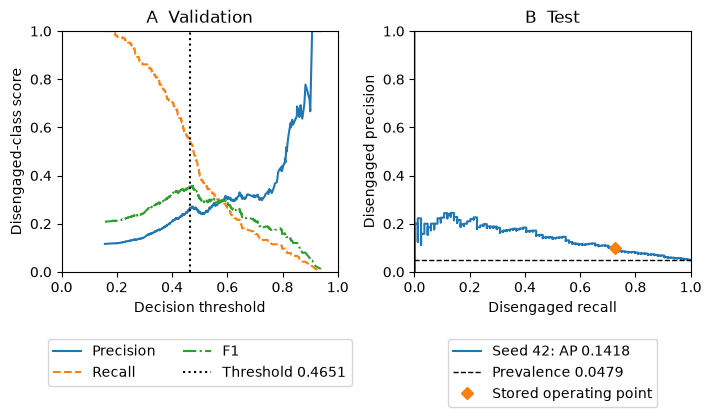

,Validation,Test
Precision,0.266862,0.098865
Recall,0.548193,0.726190


In [11]:
detector = Detector.load(resolve_checkpoint(f"{deliverable.checkpoint}"))

X_val, y_val = load_clean_split(FPS, [], "Validation", WINDOW)
val_clip_ids = load_clip_ids(FPS, [], "Validation", WINDOW)

val = per_clip(y_val, predict(detector.model, X_val), val_clip_ids)
val_row = all_runs.set_index("checkpoint").loc[deliverable.checkpoint]

precision_v, recall_v, thresholds = precision_recall_curve(val.y, val.p)
precision_v, recall_v = precision_v[:-1], recall_v[:-1]

f1_v = 2 * precision_v * recall_v / (precision_v + recall_v)

best_threshold, _, _ = best_f1_threshold_extended(val.y, val.p)

print(
    f"validation AP {average_precision_score(val.y, val.p):.4f} (stored {val_row.val_clip_ap:.4f}); "
    f"stored threshold {detector.threshold:.4f}, best-F1 threshold {best_threshold:.4f}"
)

pred = test.p >= detector.threshold

test_precision = precision_score(test.y, pred)
test_recall = recall_score(test.y, pred)
precision_t, recall_t, _ = precision_recall_curve(test.y, test.p)

fig, (ax_val, ax_test) = plt.subplots(1, 2, figsize=(7, 4), layout="constrained")

ax_val.plot(thresholds, precision_v, label="Precision")
ax_val.plot(thresholds, recall_v, label="Recall", ls="--")
ax_val.plot(thresholds, f1_v, label="F1", ls="-.")

ax_val.axvline(
    detector.threshold, color="k", ls=":", label=f"Threshold {detector.threshold:.4f}"
)

ax_val.set(
    xlim=(0, 1),
    ylim=(0, 1),
    xlabel="Decision threshold",
    ylabel="Disengaged-class score",
    title="A  Validation",
)
ax_val.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=2)

ax_test.step(
    recall_t,
    precision_t,
    where="post",
    label=f"Seed {SEED}: AP {deliverable.test_clip_ap:.4f}",
)

ax_test.axhline(
    PREVALENCE, color="k", ls="--", lw=1, label=f"Prevalence {PREVALENCE:.4f}"
)

ax_test.plot(test_recall, test_precision, "D", label="Stored operating point")

ax_test.set(
    xlim=(0, 1),
    ylim=(0, 1),
    xlabel="Disengaged recall",
    ylabel="Disengaged precision",
    title="B  Test",
)
ax_test.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25))

plt.show()


pd.DataFrame(
    {
        "Validation": [val_row.val_precision, val_row.val_recall],
        "Test": [test_precision, test_recall],
    },
    index=["Precision", "Recall"],
)

## Figure 6.5 Confusion matrix

seed 42: 61 correct alerts, 556 false alerts, 23 of 84 disengaged clips missed


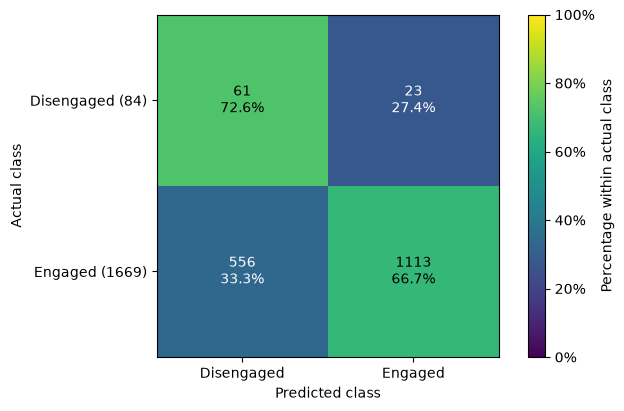

In [27]:
counts = confusion_matrix(test.y, pred, labels=[1, 0])

proportions = counts / counts.sum(axis=1, keepdims=True)

print(
    f"seed {SEED}: {counts[0, 0]} correct alerts, {counts[1, 0]} false alerts, {counts[0, 1]} of {counts[0].sum()} disengaged clips missed"
)

fig, ax = plt.subplots(figsize=(7, 4.0), layout="constrained")
im = ax.imshow(proportions, vmin=0, vmax=1)

for row in range(2):
    for col in range(2):
        ax.text(
            col,
            row,
            f"{counts[row, col]}\n{proportions[row, col]:.1%}",
            ha="center",
            va="center",
            color="white" if proportions[row, col] < 0.5 else "black",
        )

ax.set_xticks([0, 1], ["Disengaged", "Engaged"])
ax.set_yticks(
    [0, 1], [f"Disengaged ({counts[0].sum()})", f"Engaged ({counts[1].sum()})"]
)

ax.set(xlabel="Predicted class", ylabel="Actual class")

fig.colorbar(
    im,
    ax=ax,
    format=PercentFormatter(1.0),
    label="Percentage within actual class",
)

plt.show()